# Кластерный анализ

## Кластеризация стран мира по экономическим показателям

### Постановка задачи:
Выделить группы стран со схожими макроэкономическими профилями

### 1 этап - сбор и подготовка данных. 
Используем официальный API Всемирного банка через pandas_datareader

Предлагаемый набор показателей из World Development Indicators
Каждый показатель имеет чёткий экономический смысл, и в совокупности они описывают макропрофиль страны:

**Показатель |	Код WDI |	Экономическое содержание**
            
ВВП на душу населения (текущий USD)	| NY.GDP.PCAP.CD |	Уровень экономического развития

Темп роста ВВП (% годовых) |	NY.GDP.MKTP.KD.ZG |	Динамика, фаза цикла

Инфляция (потребительские цены, % годовых) |	FP.CPI.TOTL.ZG |	Ценовая стабильность

Безработица (% от рабочей силы) |	SL.UEM.TOTL.ZS (по национальной оценке) |	Состояние рынка труда

Сальдо счёта текущих операций (% ВВП) |	BN.CAB.XOKA.GD.ZS |	Внешняя сбалансированность

Государственный долг центрального правительства (% ВВП) |	GC.DOD.TOTL.GD.ZS |	Долговая нагрузка

Прямые иностранные инвестиции, чистый приток (% ВВП) |	BX.KLT.DINV.WD.GD.ZS |	Инвестиционная привлекательность / зависимость

Доля промышленности (% ВВП)	 | NV.IND.TOTL.ZS |	Структурный признак («сырьевая индустриализация» vs сервисная экономика)

In [281]:
# Установка 
!pip install pandas-datareader

In [282]:
# импорт библиотек
import pandas as pd
import numpy as np
from pandas_datareader import wb
import datetime

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [283]:
import warnings 
warnings.filterwarnings('ignore')

In [285]:
# Коды нужных индикаторов
indicators = {
    'NY.GDP.PCAP.CD': 'GDP_pc', # ВВП на душу населения
    'NY.GDP.MKTP.KD.ZG': 'GDP_growth', # Темп роста ВВП
    'FP.CPI.TOTL.ZG': 'CPI_inflation', # Инфляция (потребительские цены, % годовых)
    'SL.UEM.TOTL.ZS': 'unemployment', # Безработица (% от рабочей силы)
    'BN.CAB.XOKA.GD.ZS': 'current_account', # Сальдо счёта текущих операций (% ВВП)
    'GC.DOD.TOTL.GD.ZS': 'govt_debt', # Государственный долг центрального правительства (% ВВП)
    'BX.KLT.DINV.WD.GD.ZS': 'FDI', # Прямые иностранные инвестиции, чистый приток (% ВВП)
    'NV.IND.TOTL.ZS': 'industry_va' # Доля промышленности (% ВВП)
}

# Загружаем последний доступный полный год (2022)
df = wb.download(indicator=list(indicators.keys()),
                 country='all',
                 start=2022, end=2022)

# Приводим к удобному виду
df = df.reset_index()
df.columns = ['country', 'year'] + list(indicators.values())
df.drop('year', axis=1, inplace=True)
df.set_index('country', inplace=True)

# Сохраняем в CSV файл
df.to_csv('world_bank_indicators_2022.csv')
print(f"Данные сохранены в файл 'world_bank_indicators_2022.csv'")

Данные сохранены в файл 'world_bank_indicators_2022.csv'


In [286]:
# Посмотрим на данные
df.head(10)

,GDP_pc,GDP_growth,CPI_inflation,unemployment,current_account,govt_debt,FDI,industry_va
country,,,,,,,,
Afghanistan,357.261153,-6.240172,13.712102,14.100000,NaN,NaN,NaN,16.050368
Africa Eastern and Southern,1679.327622,3.722717,10.883478,7.869470,NaN,NaN,1.717865,26.321053
Africa Western and Central,2138.473153,4.472795,7.949251,3.593354,NaN,NaN,1.468146,23.081659
Albania,7756.961887,4.826801,6.725203,10.785000,-6.180493,58.524143,7.579340,23.025052
Algeria,4960.303343,3.600000,9.265516,12.382000,8.622970,NaN,0.107188,43.052131
American Samoa,18017.458938,1.735016,NaN,NaN,NaN,NaN,NaN,NaN
Andorra,42414.047986,9.564612,NaN,NaN,11.643448,48.115805,17.570235,11.145341
Angola,3682.113151,4.216003,21.355290,14.124000,8.964775,NaN,-5.028993,34.933359
Antigua and Barbuda,20105.198909,9.107806,7.531078,NaN,-15.006322,NaN,16.383246,19.658196


In [287]:
print("\n Пропуски по колонкам")
print(df.isnull().sum())


 Пропуски по колонкам
GDP_pc               9
GDP_growth           9
CPI_inflation       86
unemployment        32
current_account     86
govt_debt          219
FDI                 23
industry_va         25
dtype: int64


Оставляем GDP_pc, GDP_growth, CPI_inflation, unemployment - т.к будет легче интерпретировать.

Теперь задача будет звучать так: 
на основе четырёх ключевых показателей - богатство (ВВП/душу), динамика (рост ВВП), ценовая стабильность (инфляция) и рынок труда (безработица) - выделить группы стран со схожими макроэкономическими профилями.

In [288]:
# Очистим пропуски
cols_4 = ['GDP_pc', 'GDP_growth', 'CPI_inflation', 'unemployment']

df_clean = df[cols_4].dropna()

print("\n Проверка пропусков")
print(df_clean.isnull().sum())


 Проверка пропусков
GDP_pc           0
GDP_growth       0
CPI_inflation    0
unemployment     0
dtype: int64


In [289]:
# Описательная статистика
print(df_clean.describe())

              GDP_pc  GDP_growth  CPI_inflation  unemployment
count     168.000000  168.000000     168.000000    168.000000
mean    17308.547401    4.375394      13.093167      6.885511
std     23884.853832    6.548164      20.180210      5.477749
min       302.992505  -20.522479      -1.610680      0.130000
25%      2346.398608    2.597352       5.738117      3.443000
50%      6599.224740    4.188375       8.236547      5.062500
75%     20994.341831    6.006193      12.592560      8.705000
max    123719.658916   63.334634     171.205491     33.268000


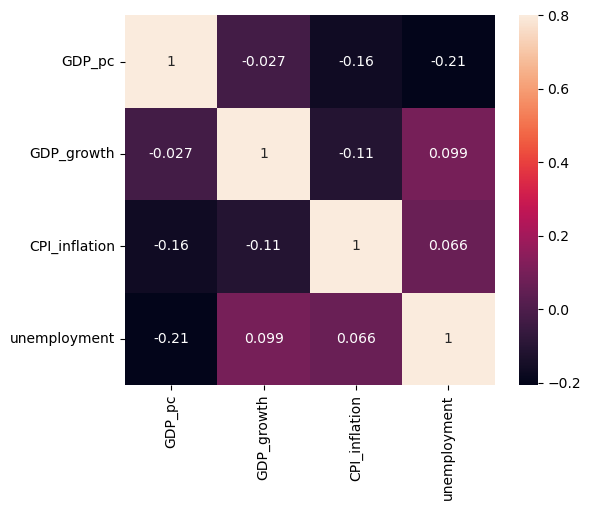

In [290]:
# Построим корреляционную матрицу
corrmat = df_clean.corr()
sns.heatmap(corrmat, vmax=.8, square=True, annot=True);

Выводы:

Корреляции слабые. Это хорошо - показатели измеряют разные аспекты экономики, дублирования нет.

Показатели ортогональны, каждый несёт свою информацию, мультиколлинеарности нет. 

### 2 этап - стандартизация

In [291]:
from sklearn import preprocessing

scaler = preprocessing.MinMaxScaler()
#scaler = preprocessing.StandardScaler()
#scaler = preprocessing.RobustScaler()
scaler.fit(df_clean)
X = scaler.transform(df_clean)

print(f"Средние: {X.mean(axis=0).round(2)}")
print(f"Std: {X.std(axis=0).round(2)}")

Средние: [0.14 0.3  0.09 0.2 ]
Std: [0.19 0.08 0.12 0.16]


### 3 этап - Иерархичсекий метод (метод Варда)

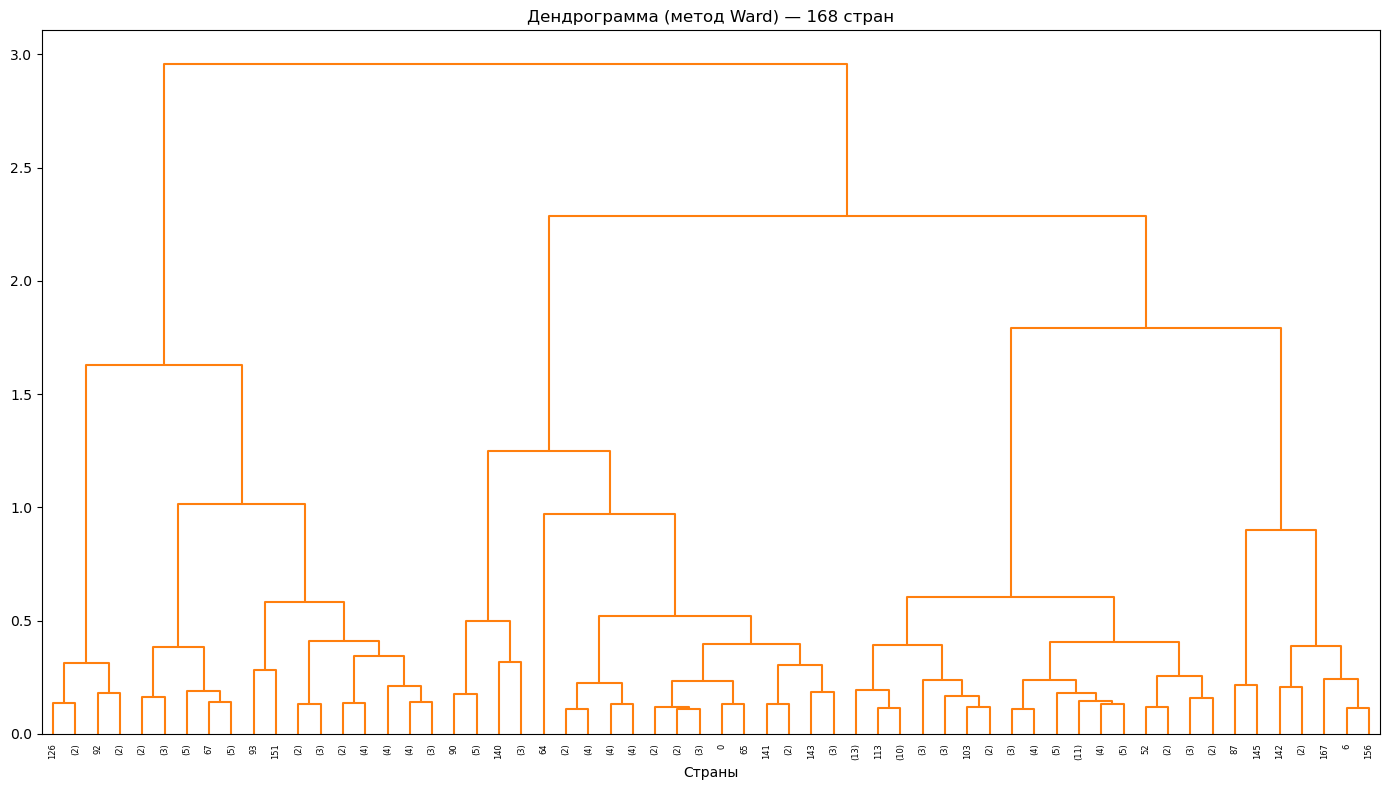

In [338]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

link = linkage(X, 'ward', 'euclidean')

# Дендрограмма
fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(111)
ax1.set_title('Дендрограмма (метод Ward) — 168 стран')
ax1.set_xlabel('Страны')

dn = dendrogram(link,
                leaf_font_size=6,
                color_threshold=8.5,      # красиво раскрасит кластеры при ~8.5
                leaf_rotation=90.,        # подписи вертикально
                truncate_mode='lastp',    # показываем последние p ветвей
                p=60)                     # топ-60 для читаемости

plt.tight_layout()
plt.show()

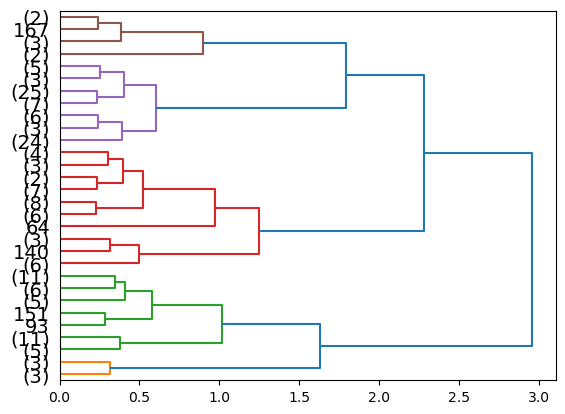

In [348]:
dn = dendrogram(link,
                leaf_font_size = 14, 
                # опция для красивого отображения слишком ветвистой дендрограммы
                # truncate_mode='lastp',
                # при расстоянии, большем 1.5, разделяем на кластеры
                color_threshold=1.5,
                # повернуть дендрограмму
                orientation = "right",
                leaf_rotation=0.,
                # при большом количестве данных дендрограмму можно подрезать
                truncate_mode='lastp')

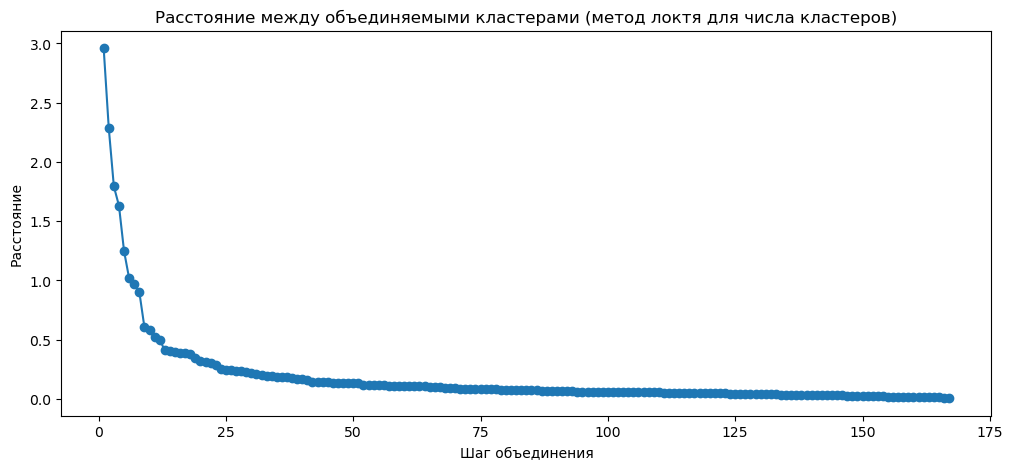

In [339]:
# Каменистая осыпь
dist = link[:, 2]
dist_rev = dist[::-1]  # расстояния в порядке убывания
idxs = range(1, len(dist) + 1)

# Полная осыпь
plt.figure(figsize=(12, 5))
plt.plot(idxs, dist_rev, marker='o')
plt.title('Расстояние между объединяемыми кластерами (метод локтя для числа кластеров)')
plt.xlabel('Шаг объединения')
plt.ylabel('Расстояние')
plt.show()

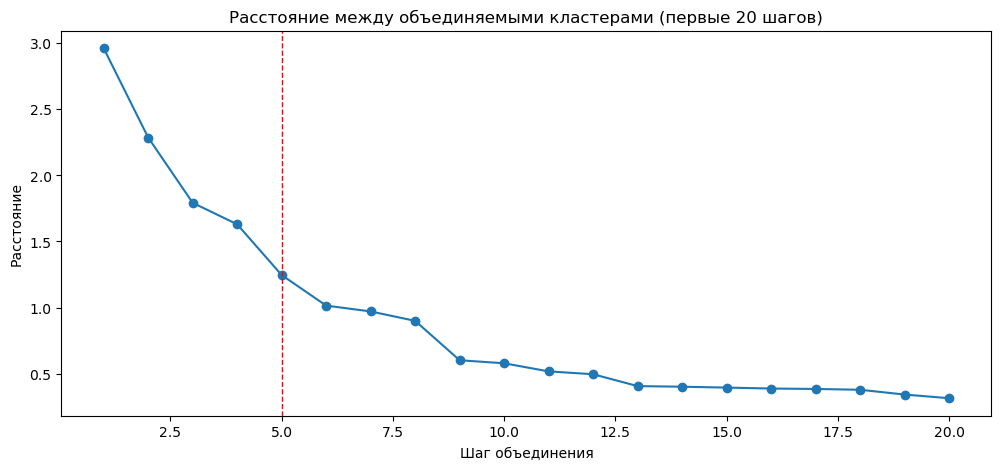

In [340]:
# Обрезанная осыпь - первые 20 шагов
d = 20
plt.figure(figsize=(12, 5))
plt.plot(idxs[:d], dist_rev[:d], marker='o')
plt.title('Расстояние между объединяемыми кластерами (первые 20 шагов)')
plt.xlabel('Шаг объединения')
plt.ylabel('Расстояние')

# Вертикальные линии для оценки числа кластеров
plt.axvline(x=5, color='red', linestyle='--', linewidth=1)
plt.show()

In [341]:
from scipy.cluster.hierarchy import fcluster

# Извлекаем 5 кластеров
k_ward = 5
labels_ward = fcluster(link, k_ward, criterion='maxclust')

df_clean['cluster_ward'] = labels_ward

print("Распределение по кластерам (Ward, k=5)")
print(df_clean['cluster_ward'].value_counts().sort_index())

Распределение по кластерам (Ward, k=5)
cluster_ward
1     6
2    40
3    41
4    73
5     8
Name: count, dtype: int64


In [344]:
from sklearn.metrics import silhouette_score

score_ward = silhouette_score(X, labels_ward)

print(score_ward)

0.40111104406488857


In [342]:
# По всем числовым колонкам
numeric_cols = df_clean.select_dtypes(include=['number']).columns
numeric_cols = [col for col in numeric_cols if col != 'cluster_ward']

# Статистика по кластерам
cluster_stats = df_clean.groupby('cluster_ward')[numeric_cols].agg(['min', 'mean', 'max'])
print(cluster_stats)

                    GDP_pc                               GDP_growth            \
                       min           mean            max        min      mean   
cluster_ward                                                                    
1             88701.468976  101929.152428  123719.658916  -1.097417  3.499497   
2              2343.249547   39834.518171   76657.248884 -20.522479  2.496355   
3               357.261153    7062.521167   30319.498720  -8.299818  5.979020   
4               302.992505    5028.378706   24620.519759  -4.658396  4.844433   
5              1046.240845    5780.663580   13962.189409  -7.349193  1.928947   

                        CPI_inflation                        unemployment  \
                    max           min       mean         max          min   
cluster_ward                                                                
1              7.511139      2.835028   5.648474    7.829457      0.13000   
2             12.000587      1.045028   8.0

In [299]:
# Посмотрим по 5-7 записей из каждого кластера
for cluster_id in sorted(df_clean['cluster_ward'].unique()):
    print(f"\n КЛАСТЕР {cluster_id} (размер: {(df_clean['cluster_ward'] == cluster_id).sum()})")
    display(df_clean[df_clean['cluster_ward'] == cluster_id].head())


 КЛАСТЕР 1 (размер: 6)


,GDP_pc,GDP_growth,CPI_inflation,unemployment,cluster_ward
country,,,,,
Ireland,105190.685953,7.511139,7.829457,4.465,1
Luxembourg,123719.658916,-1.097417,6.336008,4.588,1
Norway,109269.520580,3.246229,5.764123,3.231,1
Qatar,88701.468976,4.184970,4.995276,0.130,1
Singapore,90299.069464,4.108000,6.130954,3.591,1



 КЛАСТЕР 2 (размер: 40)


,GDP_pc,GDP_growth,CPI_inflation,unemployment,cluster_ward
country,,,,,
Australia,65169.519112,4.253046,6.594097,3.728,2
Austria,52336.772522,5.330964,8.546870,4.992,2
"Bahamas, The",34957.161328,10.877901,5.605406,9.250,2
Bahrain,30470.521928,6.180161,3.625741,1.265,2
Belgium,50605.749668,3.956238,9.597512,5.570,2



 КЛАСТЕР 3 (размер: 41)


,GDP_pc,GDP_growth,CPI_inflation,unemployment,cluster_ward
country,,,,,
Afghanistan,357.261153,-6.240172,13.712102,14.10000,3
Africa Eastern and Southern,1679.327622,3.722717,10.883478,7.86947,3
Albania,7756.961887,4.826801,6.725203,10.78500,3
Algeria,4960.303343,3.600000,9.265516,12.38200,3
Angola,3682.113151,4.216003,21.355290,14.12400,3



 КЛАСТЕР 4 (размер: 73)


,GDP_pc,GDP_growth,CPI_inflation,unemployment,cluster_ward
country,,,,,
Africa Western and Central,2138.473153,4.472795,7.949251,3.593354,4
Azerbaijan,7770.594223,4.714680,13.852259,5.650000,4
Bangladesh,2716.485928,7.099829,7.696954,4.593000,4
Belarus,7994.648061,-4.658396,15.209675,3.574000,4
Belize,7068.217280,9.250513,6.276893,8.682000,4



 КЛАСТЕР 5 (размер: 8)


,GDP_pc,GDP_growth,CPI_inflation,unemployment,cluster_ward
country,,,,,
Argentina,13962.189409,6.020745,72.430758,6.805,5
"Iran, Islamic Rep.",4721.204371,4.352811,43.488464,9.085,5
Lebanon,3654.358455,-0.621679,171.205491,11.105,5
Sri Lanka,3342.636503,-7.349193,49.721102,4.528,5
Sudan,1046.240845,-0.957817,138.808460,7.530,5


In [315]:
# Вывод в 3 столбика
for cluster_id in sorted(df_clean['cluster_ward'].unique()):
    print(f"\n КЛАСТЕР {cluster_id} ({(df_clean['cluster_ward'] == cluster_id).sum()} стран)")
    countries = df_clean[df_clean['cluster_ward'] == cluster_id].index.tolist()
    
    n = len(countries)
    col_size = (n + 2) // 3  # размер каждого столбика
    
    col1 = countries[:col_size]
    col2 = countries[col_size:2*col_size]
    col3 = countries[2*col_size:]
    
    max_len = max([len(c) for c in countries] + [10])
    
    for i in range(col_size):
        row1 = col1[i] if i < len(col1) else ''
        row2 = col2[i] if i < len(col2) else ''
        row3 = col3[i] if i < len(col3) else ''
        print(f"{row1:<{max_len}} | {row2:<{max_len}} | {row3}")


 КЛАСТЕР 1 (6 стран)
Ireland     | Norway      | Singapore
Luxembourg  | Qatar       | Switzerland

 КЛАСТЕР 2 (40 стран)
Australia            | Hong Kong SAR, China | Oman
Austria              | Hungary              | Poland
Bahamas, The         | Iceland              | Russian Federation
Bahrain              | Israel               | Saudi Arabia
Belgium              | Italy                | Slovak Republic
Brunei Darussalam    | Japan                | Slovenia
Canada               | Korea, Rep.          | Sweden
Cyprus               | Kuwait               | Timor-Leste
Czechia              | Latvia               | Trinidad and Tobago
Denmark              | Lithuania            | United Arab Emirates
Estonia              | Macao SAR, China     | United Kingdom
Finland              | Malta                | United States
France               | Netherlands          | 
Germany              | New Zealand          | 

 КЛАСТЕР 3 (41 стран)
Afghanistan                    | Djibouti         

Метод иерархической кластеризации Ward позволил выделить 5 групп стран с различными макроэкономическими характеристиками. Основная часть стран распределилась по крупным устойчивым кластерам, а небольшие кластеры отражают страны с аномальными экономическими параметрами, прежде всего высокой инфляцией или нестандартной динамикой роста.

Распределение получилось достаточно логичным: крупные группы отражают типичные экономики, а маленькие кластеры - страны с аномальными характеристиками.

**Кластер 1 (6 стран) - Развитые экономики с высокой производительностью**

GDP_pc: очень высокий (средний ~102 тыс. $) — страны с максимальным ВВП на душу

GDP_growth: умеренный рост (~3.5%)

Инфляция: умеренная (~5.65%)

Безработица: низкая (~3.35%)

Тип стран: вероятно, США, Швейцария, Норвегия, Люксембург и т.д.

**Кластер 2 (40 стран) - Экономики с высоким-средним доходом**

GDP_pc: широкий диапазон (2.3k – 76k $, средний ~40k)

GDP_growth: ~2.5%

Инфляция: повышенная (~8%)

Безработица: ~4.4%

Тип стран: Восточная Европа, некоторые развитые (возможно, Испания, Чехия, Польша)

**Кластер 3 (41 страна) - Развивающиеся с высокой инфляцией**

GDP_pc: низкий-средний (~7k $)

GDP_growth: высокий (~6%)

Инфляция: высокая (~9.7%, пик до 63%)

Безработица: высокая (~14.6%)

Тип стран: Турция, Бразилия, ЮАР, Аргентина

**Кластер 4 (73 страны) - Бедные развивающиеся / аграрные**

GDP_pc: очень низкий (~5k $)

GDP_growth: ~4.8%

Инфляция: ~10%

Безработица: ~4%

Тип стран: Индия, Индонезия, Нигерия, Вьетнам

**Кластер 5 (8 стран) - Кризисные / нестабильные**

GDP_pc: ~5.8k $

GDP_growth: очень низкий (~1.9%, даже отрицательный)

Инфляция: экстремальная (средняя ~88%, до 171%)

Безработица: ~8.4%

Тип стран: Венесуэла, Судан, Зимбабве, Ливан (гиперинфляция)

### 3 этап. Метод k-means

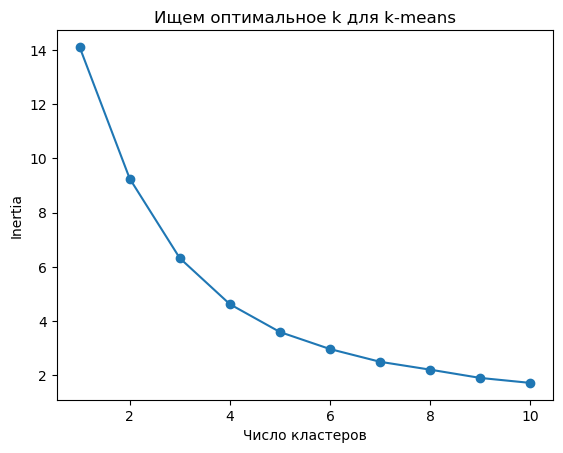

In [317]:
from sklearn.cluster import KMeans

# Метод локтя (k-means++)
K = range(1, 11)
models = [KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10, verbose=0).fit(X) for k in K]

dist = [model.inertia_ for model in models]

plt.plot(K, dist, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Inertia')
plt.title('Ищем оптимальное k для k-means')
plt.show()

k=2: silhouette = 0.4444
k=3: silhouette = 0.4496
k=4: silhouette = 0.4815
k=5: silhouette = 0.4686
k=6: silhouette = 0.4290
k=7: silhouette = 0.4271
k=8: silhouette = 0.3990
k=9: silhouette = 0.4057
k=10: silhouette = 0.3103


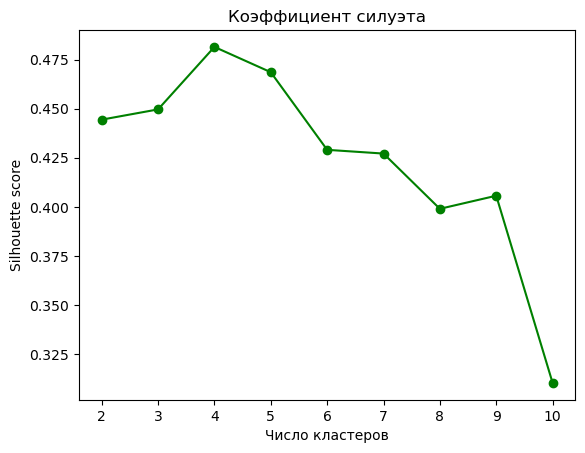

In [345]:
# Коэффициент силуэта (k от 2 до 10, для k=1 силуэт не считается)
from sklearn.metrics import silhouette_score

silhouettes = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10, verbose=0)
    labels = model.fit_predict(X)
    s = silhouette_score(X, labels)
    silhouettes.append(s)
    print(f"k={k}: silhouette = {s:.4f}")

plt.plot(range(2, 11), silhouettes, marker='o', color='green')
plt.xlabel('Число кластеров')
plt.ylabel('Silhouette score')
plt.title('Коэффициент силуэта')
plt.show()

In [347]:
model = KMeans(n_clusters=4, random_state=42, init='k-means++', n_init=10, verbose=0)
model.fit(X)

labels_kmeans = model.labels_
df_clean['cluster_kmeans'] = labels_kmeans

print(" Распределение по кластерам (k-means, k=4)")
print(df_clean['cluster_kmeans'].value_counts().sort_index())

 Распределение по кластерам (k-means, k=4)
cluster_kmeans
0    33
1    97
2    33
3     5
Name: count, dtype: int64


In [320]:
# Характеристики кластеров (средние) 
# Удаляем колонки Ward, оставляем только чистые данные
df_clean = df_clean.drop(columns=['cluster_ward', 'cluster_ward3'], errors='ignore')
print("Средние значения показателей по кластерам")
cluster_means = df_clean.groupby('cluster_kmeans').mean()
print(cluster_means.round(2))

Средние значения показателей по кластерам
                  GDP_pc  GDP_growth  CPI_inflation  unemployment
cluster_kmeans                                                   
0                7173.54        6.79           9.56         16.01
1                7375.16        3.98          11.59          4.50
2               58291.56        3.31           6.09          4.43
3                6419.41        3.20         111.89          9.20


In [321]:
# Стандартные отклонения по кластерам
print("\nСтандартные отклонения по кластерам")
print(df_clean.groupby('cluster_kmeans').std().round(2))


Стандартные отклонения по кластерам
                  GDP_pc  GDP_growth  CPI_inflation  unemployment
cluster_kmeans                                                   
0                6253.43       11.44           6.02          5.19
1                7828.72        4.32           9.25          2.27
2               24384.14        5.24           2.28          1.89
3                5668.86        3.66          43.06          1.91


In [335]:
for cluster in sorted(df_clean['cluster_kmeans'].unique()):
    print(f"\nКЛАСТЕР {cluster}")
    print()
    countries = df_clean[df_clean['cluster_kmeans'] == cluster].index.tolist()
    print(f"Стран в кластере: {len(countries)}")
    print(f"Список стран: {', '.join(countries)}")


КЛАСТЕР 0

Стран в кластере: 33
Список стран: Afghanistan, Albania, Algeria, Angola, Armenia, Bosnia and Herzegovina, Botswana, Cabo Verde, Colombia, Congo, Rep., Costa Rica, Djibouti, Gabon, Georgia, Greece, Guyana, Haiti, Iraq, Jordan, Lesotho, Libya, Mauritania, Montenegro, Namibia, Nepal, North Macedonia, Rwanda, South Africa, Spain, St. Lucia, St. Vincent and the Grenadines, Tunisia, West Bank and Gaza

КЛАСТЕР 1

Стран в кластере: 97
Список стран: Africa Eastern and Southern, Africa Western and Central, Azerbaijan, Bahrain, Bangladesh, Belarus, Belize, Benin, Bhutan, Bolivia, Brazil, Bulgaria, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Chile, China, Comoros, Cote d'Ivoire, Croatia, Czechia, Dominican Republic, Ecuador, Egypt, Arab Rep., El Salvador, Equatorial Guinea, Estonia, Ethiopia, Fiji, Gambia, The, Ghana, Guatemala, Guinea, Guinea-Bissau, Honduras, Hungary, India, Indonesia, Iran, Islamic Rep., Jamaica, Kazakhstan, Kenya, Kyrgyz Republic, L

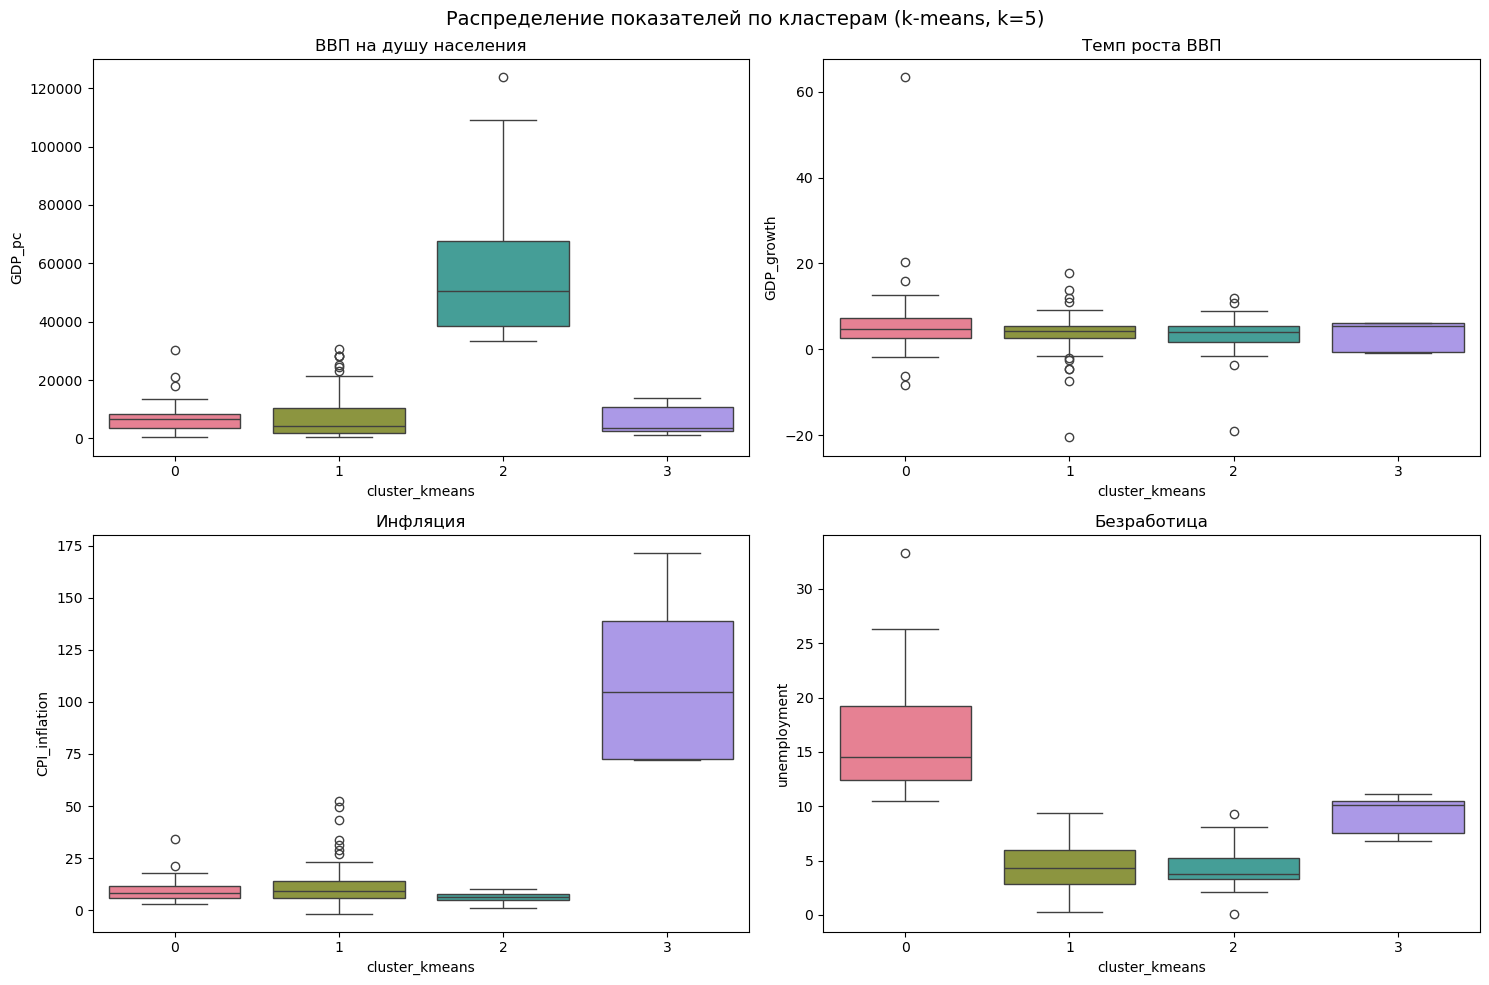

In [322]:
# Ящики с усами для всех четырёх показателей
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(x='cluster_kmeans', y='GDP_pc', data=df_clean, palette="husl", ax=axes[0,0])
axes[0,0].set_title('ВВП на душу населения')

sns.boxplot(x='cluster_kmeans', y='GDP_growth', data=df_clean, palette="husl", ax=axes[0,1])
axes[0,1].set_title('Темп роста ВВП')

sns.boxplot(x='cluster_kmeans', y='CPI_inflation', data=df_clean, palette="husl", ax=axes[1,0])
axes[1,0].set_title('Инфляция')

sns.boxplot(x='cluster_kmeans', y='unemployment', data=df_clean, palette="husl", ax=axes[1,1])
axes[1,1].set_title('Безработица')

plt.suptitle('Распределение показателей по кластерам (k-means, k=5)', fontsize=14)
plt.tight_layout()
plt.show()

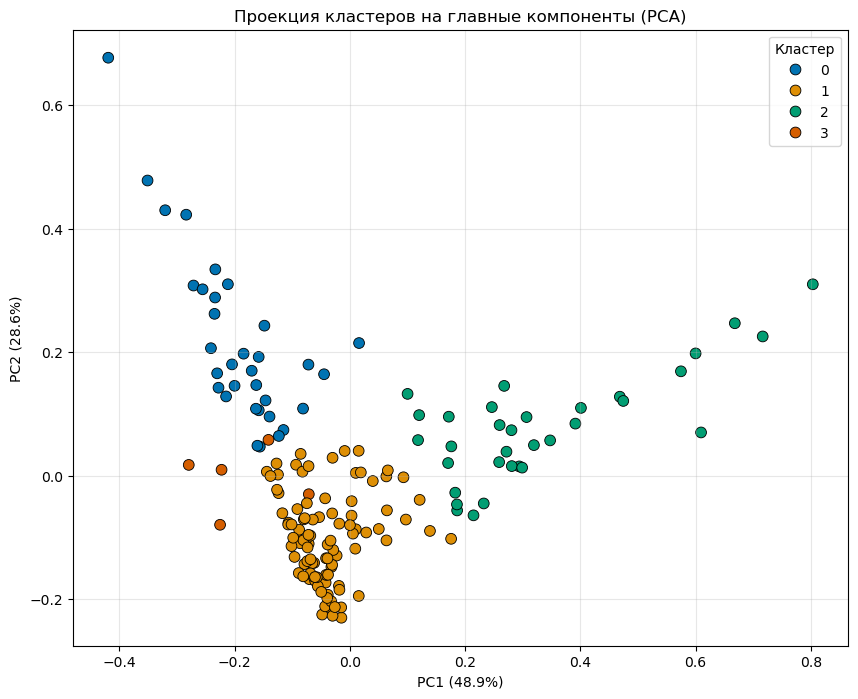

PC1 объясняет: 48.9%
PC2 объясняет: 28.6%
Суммарно: 77.4%


In [323]:
# Проекция на главные компоненты (PCA)
from sklearn import decomposition

pca = decomposition.PCA(n_components=2)
pca_features = pca.fit_transform(X)

xdata = pca_features[:, 0]
ydata = pca_features[:, 1]

df_pca = pd.DataFrame({'xdata': xdata, 'ydata': ydata, 'cluster': df_clean['cluster_kmeans']})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x="xdata", y="ydata", hue='cluster', palette="colorblind", s=60, edgecolor='black')
plt.title("Проекция кластеров на главные компоненты (PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(title='Кластер')
plt.grid(alpha=0.3)
plt.show()

print(f"PC1 объясняет: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2 объясняет: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Суммарно: {pca.explained_variance_ratio_.sum():.1%}")

In [324]:
from sklearn.manifold import MDS

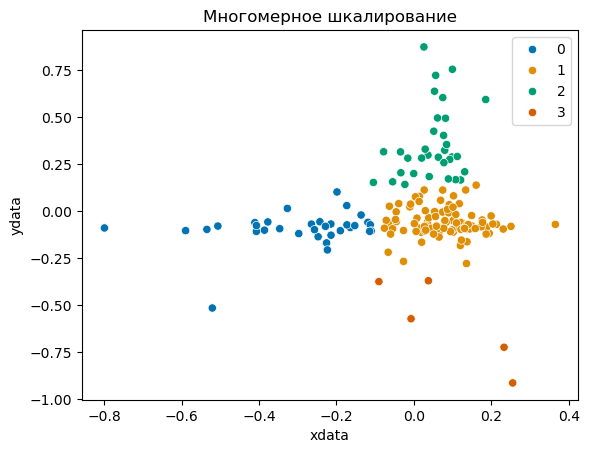

In [326]:
mds = MDS(n_components=2,
          n_init=12,
          max_iter=1000,
          metric=True,
          n_jobs=4,
          random_state=42)

Х_mds = mds.fit_transform(X)

df_mds = pd.DataFrame(data=Х_mds, columns=['xdata', 'ydata'])

sns.scatterplot(data=df_mds, x="xdata", y="ydata", hue=model.labels_, palette = "colorblind")
plt.title("Многомерное шкалирование")
plt.show()

**Вывод по кластерам**

Анализ выделил 4 группы стран с принципиально разными экономическими профилями:

**Кластер 2 (33 страны)** - **развитые экономики**: аномально высокий ВВП на душу ($58 тыс.), низкая инфляция (6%) и безработица (4,4%). Самый благополучный кластер.

**Кластер 1 (97 стран)** - **развивающиеся экономики со средней доходностью**: умеренный ВВП ($7,4 тыс.), высокая инфляция (11,6%), но низкая безработица (4,5%). Самый многочисленный.

**Кластер 0 (33 страны)** - **проблемные экономики**: низкий ВВП ($7,2 тыс.), высокая безработица (16%) при умеренной инфляции (9,6%). Включает Грецию, Испанию, ЮАР, Афганистан.

**Кластер 3 (5 стран)** - **кризисные экономики**: экстремально высокая инфляция (112%), очень низкий ВВП ($6,4 тыс.). Аргентина, Ливан, Судан, Турция, Зимбабве - группа с гиперинфляцией.

Метод k-means дал более компактное и устойчивое разбиение данных. Оптимальное число кластеров было выбрано на основе коэффициента силуэта и метода локтя.

Распределение кластеров получилось следующим:

33 страны
97 стран
33 страны
5 стран

Метод выделил:

- развитые экономики с высоким GDP per capita;
- 
- страны со стабильной экономикой;
- 
- страны с высокой безработицей;
- 
- небольшую группу государств с гиперинфляцией.

Средние значения кластеров показывают, что сегменты хорошо различаются между собой по ключевым показателям. Например, один кластер имеет GDP per capita около 58 тыс. $, а другой - экстремальную инфляцию свыше 111%.


Общий вывод: метод показал наиболее качественную кластеризацию с точки зрения компактности и разделимости групп.

### 4 этап - DBscan

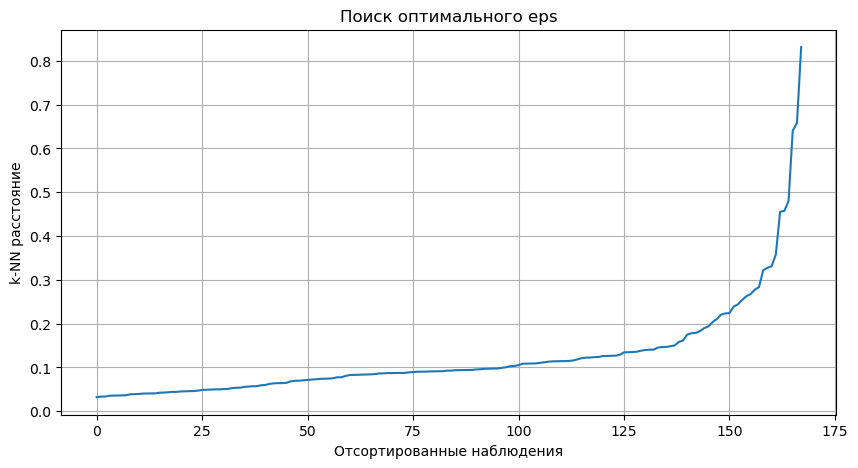

In [327]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# График k-NN расстояний для выбора eps
minPts = 10
nbrs = NearestNeighbors(n_neighbors=minPts).fit(X)
distances, indices = nbrs.kneighbors(X)
sort_distances = np.sort(distances[:, minPts-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(sort_distances)
plt.ylabel(f"k-NN расстояние")
plt.xlabel("Отсортированные наблюдения")
plt.grid(True)
plt.title("Поиск оптимального eps")
plt.show()

In [328]:
# Перебор eps при фиксированном minPts=13
for eps_val in [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    db = DBSCAN(eps=eps_val, min_samples=13)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps_val}: кластеров = {n_clusters}, шум = {n_noise} ({(n_noise/len(X)*100):.0f}%)")

eps=0.2: кластеров = 1, шум = 12 (7%)
eps=0.25: кластеров = 1, шум = 7 (4%)
eps=0.3: кластеров = 1, шум = 4 (2%)
eps=0.35: кластеров = 1, шум = 3 (2%)
eps=0.4: кластеров = 1, шум = 3 (2%)
eps=0.5: кластеров = 1, шум = 1 (1%)


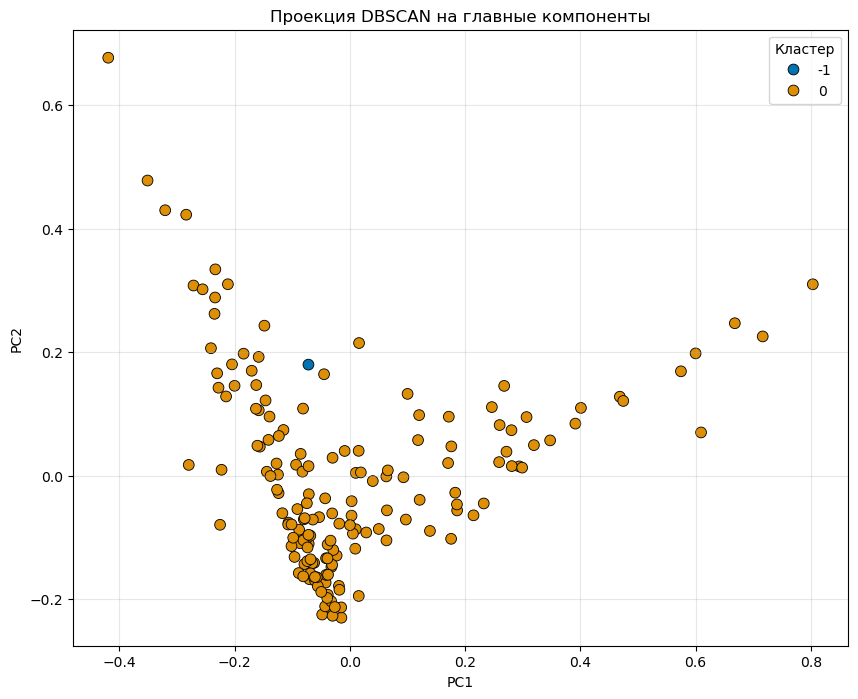

In [329]:
db_best = DBSCAN(eps=0.45, min_samples=8)
labels_best = db_best.fit_predict(X)

pca = decomposition.PCA(n_components=2)
pca_features = pca.fit_transform(X)

xdata = pca_features[:, 0]
ydata = pca_features[:, 1]

df_pca = pd.DataFrame({'xdata': xdata, 'ydata': ydata, 'cluster': labels_best})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x="xdata", y="ydata", hue='cluster', palette="colorblind", s=60, edgecolor='black')
plt.title("Проекция DBSCAN на главные компоненты")
plt.xlabel(f"PC1")
plt.ylabel(f"PC2")
plt.legend(title='Кластер')
plt.grid(alpha=0.3)
plt.show()

**Вывод по методу**: DBSCAN не смог выделить устойчивые плотностные группы в данных. Метод не сработал!

## Заключение

В ходе работы были применены три метода кластеризации: Ward, k-means и DBSCAN.

Метод DBSCAN не смог выделить устойчивые плотностные группы в данных, поэтому оказался наименее подходящим для данного набора макроэкономических показателей.

Метод Ward показал хорошие результаты для исследовательского анализа:

- позволил выявить структуру данных;
- обнаружил аномальные экономики;
- выделил группы стран с похожими экономическими характеристиками.

k-means:

- обеспечил наилучший коэффициент силуэта;
- сформировал  компактные и четко разделенные кластеры.

Таким образом, метод k-means показал лучшие количественные показатели качества кластеризации по silhouette score, что свидетельствует о более компактном разделении объектов.

**Однако метод Ward** обеспечил более содержательно интерпретируемое разбиение стран. Он позволил выделить дополнительные экономически значимые группы.

В контексте анализа стран метод Ward оказался более полезным с аналитической точки зрения, несмотря на несколько более низкие количественные метрики качества.